<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Line Charts**


Estimated time needed: **30** minutes


In this lab, you will focus on using line charts to analyze trends over time and across different categories in a dataset.



## Objectives


In this lab you will perform the following:


- Track trends in compensation across age groups and specific age ranges.

- Analyze job satisfaction trends based on experience level.

- Explore and interpret line charts to identify patterns and trends.


## Setup: Working with the Database
**Install the needed libraries**


In [1]:
#!pip install pandas


In [2]:
#!pip install matplotlib

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



#### Step 1: Download the dataset


In [3]:
#!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv


#### Step 2: Import necessary libraries and load the dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


#### Load the data


In [2]:
df = pd.read_csv(r"C:\Users\lenovo-miguel\OneDrive\IBM_Data_Analytics_Coursera\survey-data.csv")


#### Display the first few rows to understand the structure of the data


In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Trends in Compensation Over Age Groups


##### 1. Line Chart of Median `ConvertedCompYearly` by Age Group


- Track how the median yearly compensation (ConvertedCompYearly) changes across different age groups.

- Use a line chart to visualize these trends.


In [4]:
#let's get a specific dataset to do this analysis, excluding missing values and responses with 'Prefer not to say' for Age
df_age_ccy = df[['Age', 'ConvertedCompYearly']].dropna()
df_age_ccy = df_age_ccy[df_age_ccy['Age']!='Prefer not to say']
print(df_age_ccy.shape)
df_age_ccy.describe()


(23426, 2)


,ConvertedCompYearly
count,2.342600e+04
mean,8.613250e+04
std,1.867864e+05
min,1.000000e+00
25%,3.271200e+04
50%,6.500000e+04
75%,1.079370e+05
max,1.625660e+07


In [5]:
#As we have already seen in other labs, ConvertedCompYearly has outliers, let's remove them for a better analysis
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.079370e+05
q1 = 3.271200e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_age_ccy_no_outliers = df_age_ccy[df_age_ccy['ConvertedCompYearly']<=out_upper]
print(df_age_ccy_no_outliers.shape)

IQR =  75225.0
Upper bound for outliers =  220774.5
Lower bound for outliers =  -80125.5
(22449, 2)


In [6]:
#let's group by Age taking the median of ConvertedCompYearly
median_ccy_age = df_age_ccy_no_outliers.groupby('Age')['ConvertedCompYearly'].median().reset_index()
#let's define Age as an oredered categorical column and order the dataframe by it, to have the right order for the x-axis values
age_order = ['Under 18 years old', '18-24 years old', '25-34 years old', '35-44 years old', '45-54 years old', '55-64 years old', '65 years or older']
median_ccy_age['Age'] = pd.Categorical(median_ccy_age['Age'], categories=age_order, ordered=True)
median_ccy_age = median_ccy_age.sort_values('Age')
median_ccy_age

,Age,ConvertedCompYearly
6,Under 18 years old,7253.0
0,18-24 years old,24707.0
1,25-34 years old,58000.0
2,35-44 years old,80000.0
3,45-54 years old,91295.0
4,55-64 years old,105000.0
5,65 years or older,100000.0


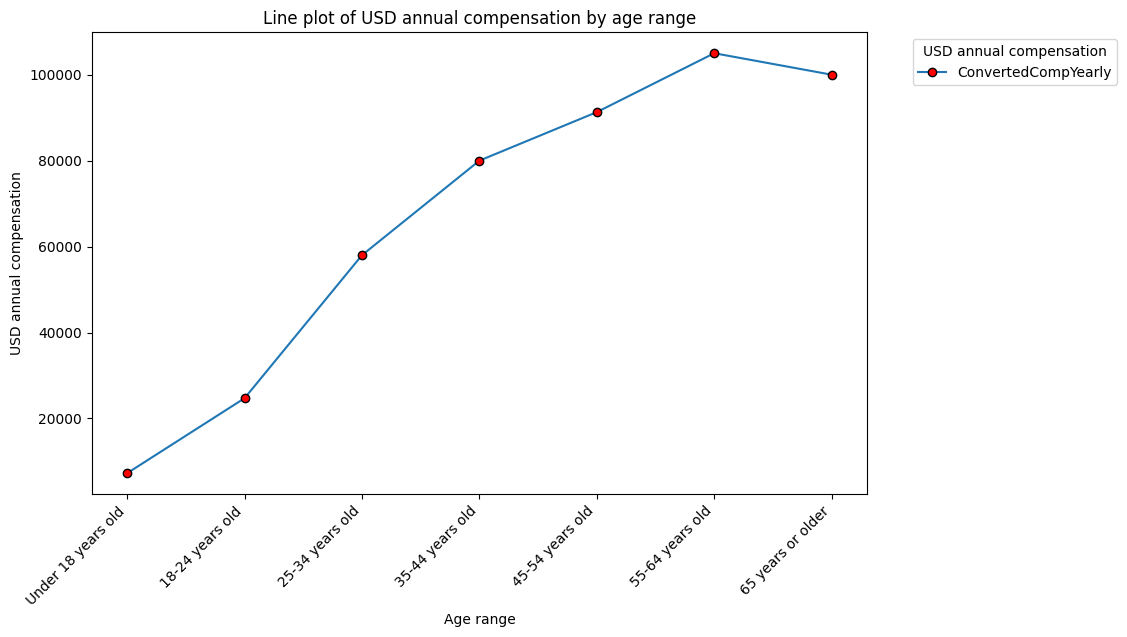

In [9]:
#let's plot the line chart
fig, ax = plt.subplots(figsize=(10, 6))
median_ccy_age.plot(x='Age', y='ConvertedCompYearly', kind='line', marker='o', markerfacecolor='red', markeredgecolor='black', ax=ax )
plt.title('Line plot of USD annual compensation by age range')
plt.xlabel('Age range')
plt.ylabel('USD annual compensation')
plt.xticks(rotation=45, ha='right')
plt.legend(title='USD annual compensation', bbox_to_anchor=(1.05, 1))
plt.show()

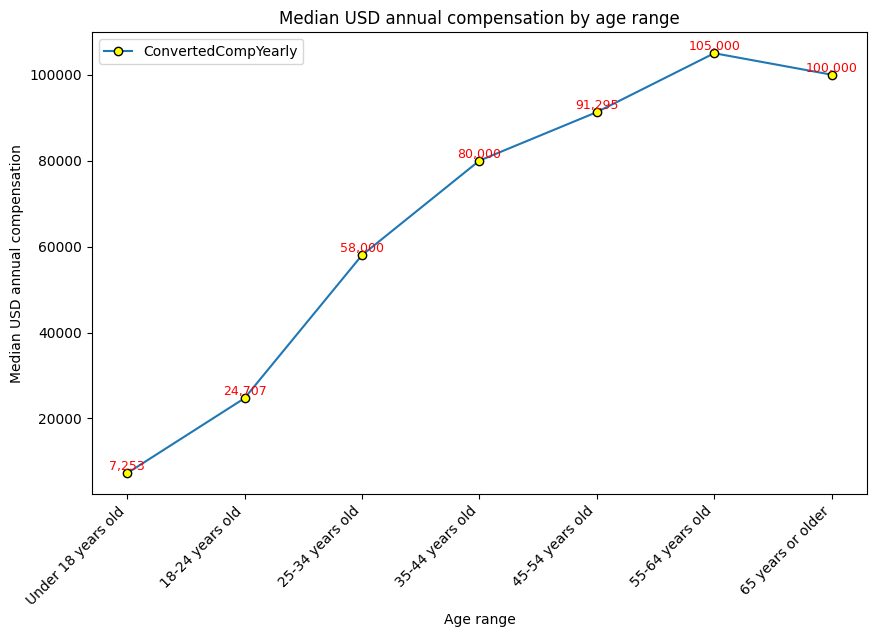

In [10]:
#we can improve the chart by annotating the y-value besides each point of the line
fig, ax = plt.subplots(figsize=(10, 6))
line = median_ccy_age.plot(x='Age', y='ConvertedCompYearly', kind='line', marker='o', markerfacecolor='yellow', markeredgecolor='black', ax=ax )
#get coordinates of each point of the line
x_coords = line.lines[0].get_xdata()
y_coords = line.lines[0].get_ydata()
#Annotate
for x, y in zip(x_coords, y_coords):
    ax.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=9, color='red')
plt.title('Median USD annual compensation by age range')
plt.xlabel('Age range')
plt.ylabel('Median USD annual compensation')
plt.xticks(rotation=45, ha='right')
#plt.legend(title='Median USD annual compensation', bbox_to_anchor=(1.05, 1))
plt.savefig(r'C:\Users\lenovo-miguel\OneDrive\IBM_Data_Analytics_Coursera\Capstone_Project\median_CCY_by_age.png', dpi=300, bbox_inches="tight")
plt.show()

##### 2. Line Chart of Median `ConvertedCompYearly` for Ages 25 to 45


For a closer look, plot a line chart focusing on the median compensation for respondents between ages 25 and 45.


###We have again the problem we had in other tasks of the Capstone project: the task is stated implying that 'Age' is a numerical variable, but it is not that, it is a ctegorical variable specifiyng an 'age range'... I think that, to fulfill the task statement, the better I can do is to plot a chart showing median compensation for age ranges '25-34 years old' and '35-44 years old'.

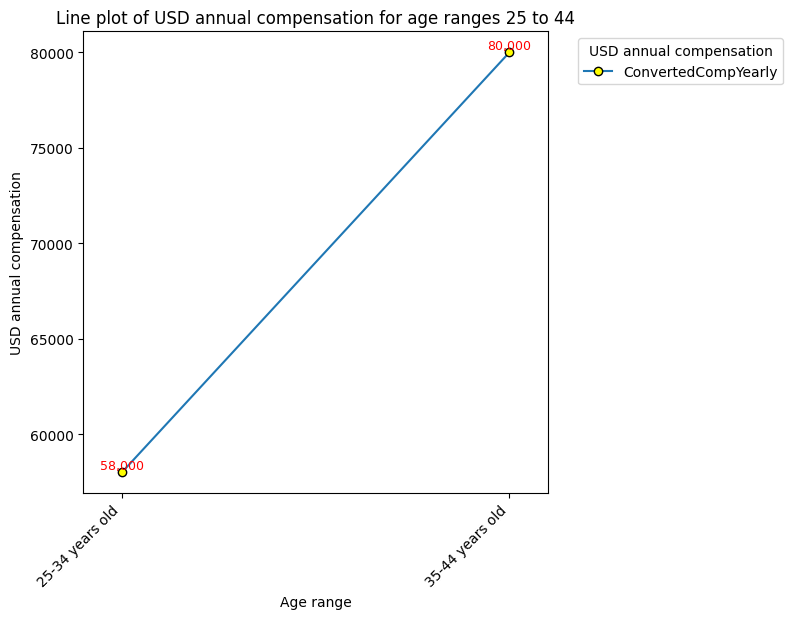

In [11]:
#let's get a dataframe with only the ranges to be plotted
median_ccy_age_25to44 = median_ccy_age[(median_ccy_age['Age']=='25-34 years old') | (median_ccy_age['Age']=='35-44 years old')].copy()
#let's define Age as an ordered categorical column and order the dataframe by it, to have the right order for the x-axis values
age_order = ['25-34 years old', '35-44 years old']
median_ccy_age_25to44['Age'] = pd.Categorical(median_ccy_age_25to44['Age'], categories=age_order, ordered=True)
median_ccy_age_25to44 = median_ccy_age_25to44.sort_values('Age')
#let's plot the chart
fig, ax = plt.subplots(figsize=(6, 6))
line = median_ccy_age_25to44.plot(x='Age', y='ConvertedCompYearly', kind='line', marker='o', markerfacecolor='yellow', markeredgecolor='black', ax=ax )
#get coordinates of each point of the line
x_coords = line.lines[0].get_xdata()
y_coords = line.lines[0].get_ydata()
#Annotate
for x, y in zip(x_coords, y_coords):
    ax.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=9, color='red')
plt.title('Line plot of USD annual compensation for age ranges 25 to 44')
plt.xlabel('Age range')
plt.ylabel('USD annual compensation')
ax.set_xticks([0, 1])
ax.set_xticklabels(age_order, rotation=45, ha='right')
plt.legend(title='USD annual compensation', bbox_to_anchor=(1.05, 1))
ax.set_xlim(min(x_coords) - 0.1, max(x_coords) + 0.1)
plt.show()

###Additional exercise: 'Line chart for 'CompTotal' trends for ages 45-60'. This exercise is listed in the 'Checklist: Visualizing Comparison of Data' of the Capstone Project, I will do it to be able to answer 'Yes' to its completion!

I will plot a line chart of median CompTotal for the age ranges '45-54 years old' and '55-64 years old', because Age is not a numerical variable, and I can't pinpoint a '45-60 years old' range. This approach is, I think, the best I can do...

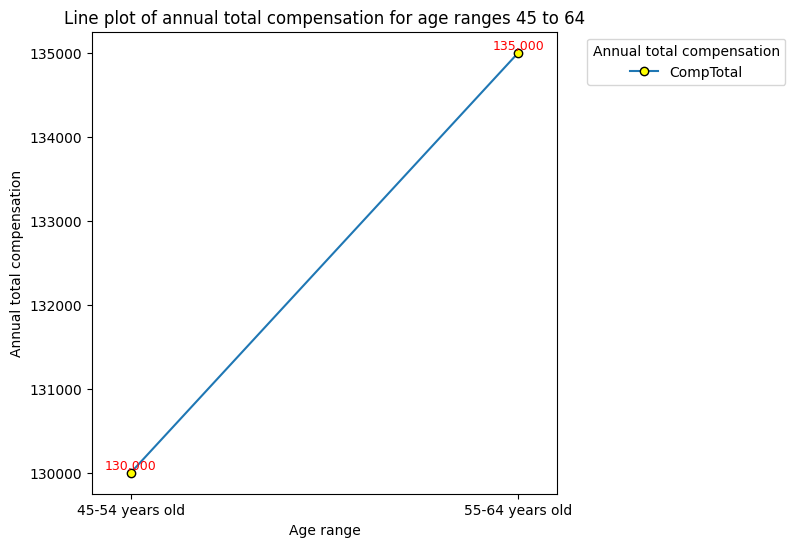

In [4]:
#let's get a specific dataframe for this analysis
df_ct_age = df[['Age', 'CompTotal']].dropna()
df_ct_age_45to64 = df_ct_age[(df_ct_age['Age']=='45-54 years old') | (df_ct_age['Age']=='55-64 years old')]
#let's group by Age and get the CompTotal medians
median_ct_age_45to64 = df_ct_age_45to64.groupby('Age').median('CompTotal').reset_index()
#let's define Age as an ordered categorical column and order the dataframe by it, to have the right order for the x-axis values
age_order = ['45-54 years old', '55-64 years old']
median_ct_age_45to64['Age'] = pd.Categorical(median_ct_age_45to64['Age'], categories=age_order, ordered=True)
median_ct_age_45to64 = median_ct_age_45to64.sort_values('Age')
#let's plot the chart
fig, ax = plt.subplots(figsize=(6, 6))
line = median_ct_age_45to64.plot(x='Age', y='CompTotal', kind='line', marker='o', markerfacecolor='yellow', markeredgecolor='black', ax=ax )
#get coordinates of each point of the line
x_coords = line.lines[0].get_xdata()
y_coords = line.lines[0].get_ydata()
#Annotate
for x, y in zip(x_coords, y_coords):
    ax.text(x, y, f'{y:,.0f}', ha='center', va='bottom', fontsize=9, color='red')
plt.title('Line plot of annual total compensation for age ranges 45 to 64')
plt.xlabel('Age range')
plt.ylabel('Annual total compensation')
ax.set_xticks([0, 1])
ax.set_xticklabels(age_order, rotation=0, ha='center')
plt.legend(title='Annual total compensation', bbox_to_anchor=(1.05, 1))
ax.set_xlim(min(x_coords) - 0.1, max(x_coords) + 0.1)
plt.show()

### Task 2: Trends in Job Satisfaction by Experience Level



##### 1. Line Chart of Job Satisfaction (`JobSatPoints_6`) by Experience Level



- Use a column that approximates experience level to analyze how job satisfaction changes with experience.

- If needed, substitute an available experience-related column for `Experience`.


###I will use YearsCodePro to define experience level

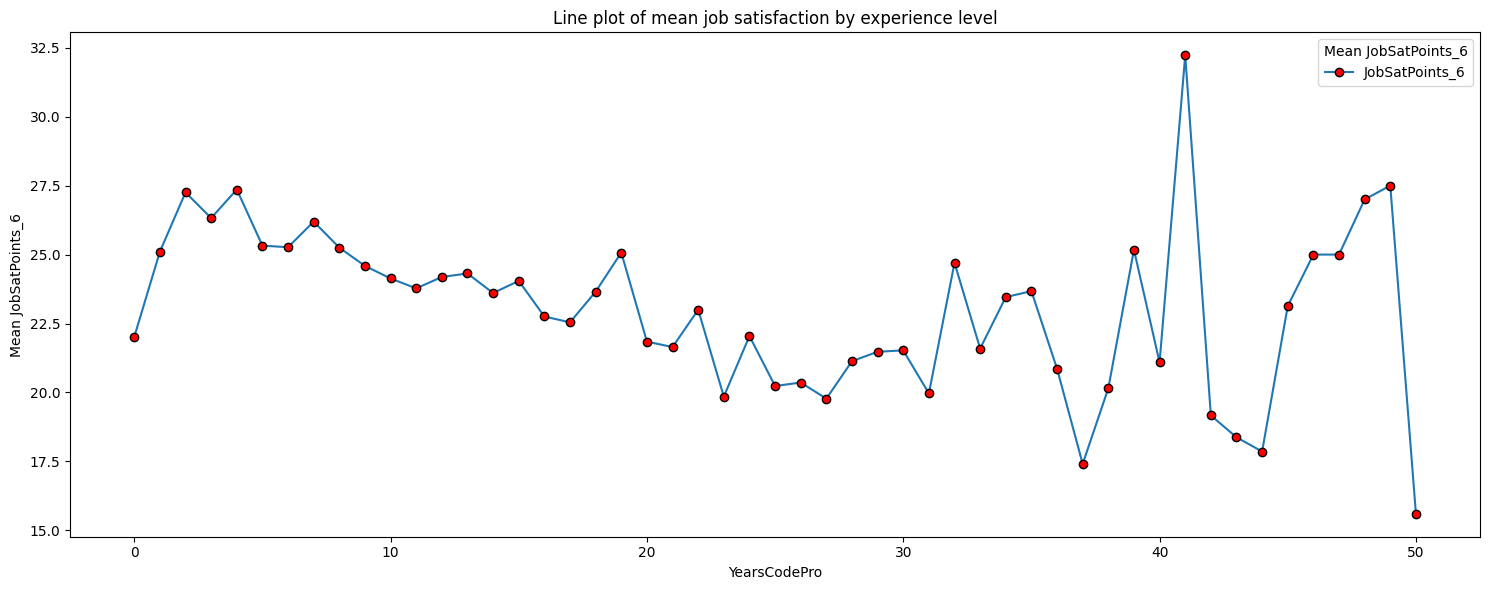

In [12]:
#let's get a specific dataframe to do this analysis
df_js6_ycp = df[['YearsCodePro', 'JobSatPoints_6']].dropna()
#YearsCodePro is a categorical column; let's turn it to a numerical column; we will replace 'Less than 1 year' by 0 and 'More than 50 years' by 50
df_js6_ycp['YearsCodePro'] = df_js6_ycp['YearsCodePro'].replace({'Less than 1 year': '0', 'More than 50 years':'50'}).astype(float)
#let's group by YearsCodePro taking the mean of JobSatPoints_6 for each value of YearCodePro
js6_by_ycp = df_js6_ycp.groupby('YearsCodePro')['JobSatPoints_6'].mean().reset_index()
#let's plot the line chart
fig, ax = plt.subplots(figsize=(15, 6))
js6_by_ycp.plot(x='YearsCodePro', y='JobSatPoints_6', kind='line', marker='o', markerfacecolor='red', markeredgecolor='black', ax=ax )
plt.title('Line plot of mean job satisfaction by experience level')
plt.xlabel('YearsCodePro')
plt.ylabel('Mean JobSatPoints_6')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Mean JobSatPoints_6')
plt.tight_layout()
plt.show()

### Task 3: Trends in Job Satisfaction and Compensation by Experience


##### 1.Line Chart of Median ConvertedCompYearly Over Experience Level

- This line chart will track how median compensation (`ConvertedCompYearly`) changes with increasing experience.

- Use a column such as `WorkExp` or another relevant experience-related column.


###I will use YearsCodePro to define experience level

In [13]:
#let's get a specific dataframe to do this analysis
df_ccy_ycp = df[['YearsCodePro', 'ConvertedCompYearly']].dropna()
print(df_ccy_ycp.shape)
df_ccy_ycp.describe()

(23345, 2)


,ConvertedCompYearly
count,2.334500e+04
mean,8.618139e+04
std,1.868760e+05
min,1.000000e+00
25%,3.295400e+04
50%,6.515200e+04
75%,1.080000e+05
max,1.625660e+07


IQR =  75046.0
Upper bound for outliers =  220569.0
Lower bound for outliers =  -79615.0


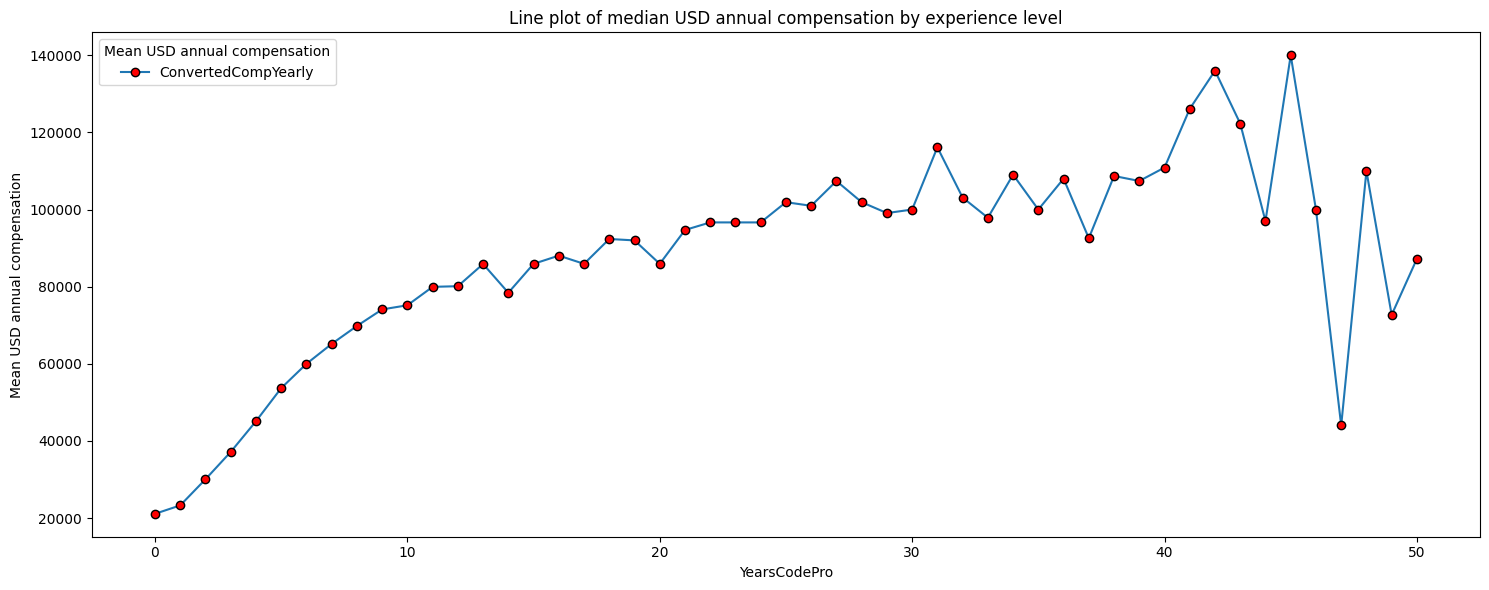

In [14]:
#As we have already seen in other labs, ConvertedCompYearly has outliers, let's remove them for a better analysis
#let's calculate the interquartile range for ConvertedCompYearly using the values produced by describe() (Q3  and Q1)
q3 = 1.080000e+05
q1 = 3.295400e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)
df_ccy_ycp_no_outliers = df_ccy_ycp[df_ccy_ycp['ConvertedCompYearly']<=out_upper].copy()
#YearsCodePro is a categorical column; let's turn it to a numerical column; we will replace 'Less than 1 year' by 0 and 'More than 50 years' by 50
df_ccy_ycp_no_outliers['YearsCodePro'] = df_ccy_ycp_no_outliers['YearsCodePro'].replace({'Less than 1 year': '0', 'More than 50 years':'50'}).astype(float)
#let's group by YearsCodePro taking the median of ConvertedCompYearly for each value of YearCodePro
ccy_by_ycp = df_ccy_ycp_no_outliers.groupby('YearsCodePro')['ConvertedCompYearly'].median().reset_index()
#let's plot the line chart
fig, ax = plt.subplots(figsize=(15, 6))
ccy_by_ycp.plot(x='YearsCodePro', y='ConvertedCompYearly', kind='line', marker='o', markerfacecolor='red', markeredgecolor='black', ax=ax )
plt.title('Line plot of median USD annual compensation by experience level')
plt.xlabel('YearsCodePro')
plt.ylabel('Mean USD annual compensation')
plt.xticks(rotation=0, ha='center')
plt.legend(title='Mean USD annual compensation')
plt.tight_layout()
plt.show()

##### 2.Line Chart of Job Satisfaction (`JobSatPoints_6`) Across Experience Levels

- Create a line chart to explore trends in job satisfaction (`JobSatPoints_6`) based on experience level.

- This chart will provide insight into how satisfaction correlates with experience over time


In [15]:
## Write your code here
#THIS IS THE SAME AS TASK 2, WE HAVE ALREADY DONE IT!

#### Final Step: Review


In this lab, you focused on analyzing trends in compensation and job satisfaction, specifically exploring how these metrics change with age and experience levels using line charts.


### Summary


In this lab, you explored essential data visualization techniques with a focus on analyzing trends using line charts. You learned to:

- Visualize the distribution of compensation across age groups to understand salary trends.

- Track changes in median compensation over various experience levels, identifying how earnings progress with experience.

- Examine trends in job satisfaction by experience, revealing how satisfaction varies throughout a developer's career.

These analyses allow for a deeper understanding of how factors like age and experience influence job satisfaction and compensation. By using line charts, you gained insights into continuous data patterns, which are invaluable for interpreting professional trends in the developer community.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-10-28|1.2|Madhusudhan Moole|Updated lab|
|2024-10-16|1.1|Madhusudhan Moole|Updated lab|
|2024-10-15|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
